# Text Classification with BERTweet


In this notebook a **tweet emotion classifier** it's built using the Hugging Face ecosystem.
The goal is to classify short English tweets into one of six emotions:
**sadness, joy, love, anger, fear, and surprise**.

Tweets are short (<=280 chars), informal, and often ambiguous. This makes them an excellentstress-test for NLP models, especially for fine-grained emotion classification. We compare **BERTweet base** (`vinai/bertweet-base`) against **BERTweet large** (`vinai/bertweet-large`).
Both are RoBERTa-base style models pre-trained on hundreds of millions of tweets, and are well-suited for social-media text.

We run three training stages for the base model and then compare base vs large on full fine-tuning:
1. **Featurizer (frozen base)** - only the classifier head is trained
2. **Custom deeper head (frozen base)** - replace the linear head with a multi-layer MLP
3. **Full fine-tuning** - all model layers are trainable


#### References
- Dataset: https://huggingface.co/datasets/dair-ai/emotion
- Model: https://huggingface.co/vinai/bertweet-base
- BERTweet paper: https://arxiv.org/abs/1910.01108


## 0. Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print('Running in Colab:', IN_COLAB)


Running in Colab: True


## 1. Dataset Loading

We use the `dair-ai/emotion` dataset. It contains ~20k English tweets labeled with one of six emotions.


In [2]:
!pip install torchinfo

In [3]:
from datasets import load_dataset

raw_datasets = load_dataset('dair-ai/emotion')
raw_datasets


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

**Note:** The dataset is moderately imbalanced. We should expect lower performance on
minority classes (*love* and *surprise*) unless we compensate during training.


In [4]:
# Build label maps from dataset features.
labels = raw_datasets['train'].features['label'].names
id2label = {i: l for i, l in enumerate(labels)}
label2id = {l: i for i, l in id2label.items()}
NUM_LABELS = len(labels)
labels


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

## 2. Exploratory Data Analysis

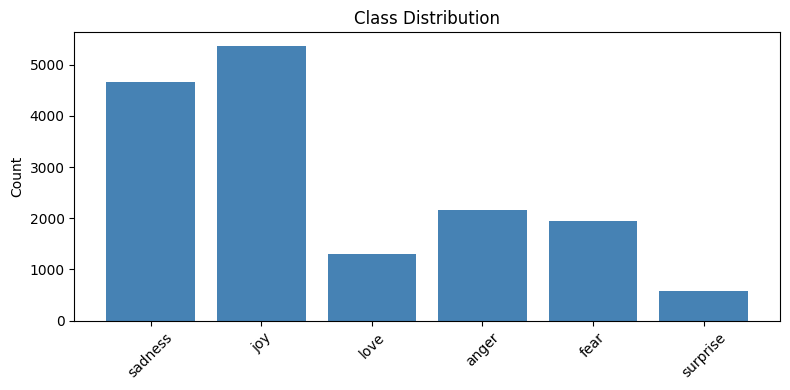

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = raw_datasets['train'].to_pandas()

# Class distribution
class_counts = train_df['label'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.bar([id2label[i] for i in class_counts.index], class_counts.values, color='steelblue')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


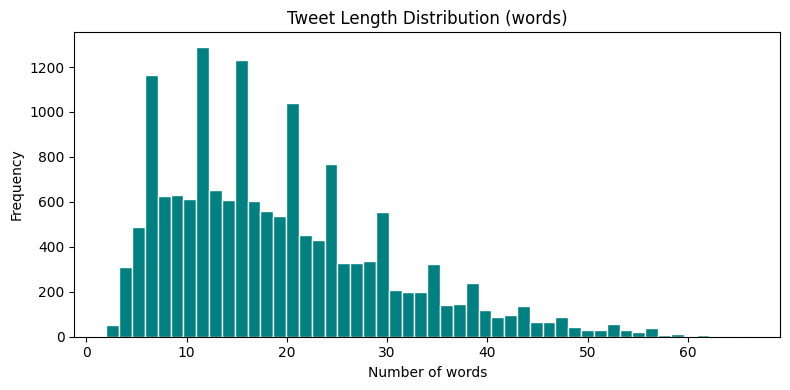

Median length: 17
95th percentile: 41


In [6]:
# Text length distribution
text_lengths = train_df['text'].str.split().map(len)
plt.figure(figsize=(8,4))
plt.hist(text_lengths, bins=50, color='teal', edgecolor='white')
plt.title('Tweet Length Distribution (words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Median length:', int(np.median(text_lengths)))
print('95th percentile:', int(np.percentile(text_lengths, 95)))


**Note:** Tweets are short. A `max_length` of 64 tokens is usually enough and saves
GPU memory without losing information.


## 3. Tokenizer

In [7]:
from transformers import AutoTokenizer

BASE_CKPT = 'vinai/bertweet-base'
LARGE_CKPT = 'vinai/bertweet-large'
MODEL_CKPT = BASE_CKPT
MAX_LEN = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT, use_fast=False)
print('Vocab size:', tokenizer.vocab_size)
print('Model max length:', tokenizer.model_max_length)
print('Model inputs:', tokenizer.model_input_names)


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Vocab size: 64000
Model max length: 1000000000000000019884624838656
Model inputs: ['input_ids', 'attention_mask']


In [8]:
# Inspect how a typical tweet is tokenized.
sample_tweet = "omg i feel SO happy right now, best day ever!!"
encoded = tokenizer(sample_tweet, max_length=MAX_LEN, truncation=True, padding='max_length')
input_ids = encoded['input_ids']
tokens = tokenizer.convert_ids_to_tokens(input_ids)
pad_token = tokenizer.pad_token or '<pad>'
print('Tokens:', [t for t in tokens if t != pad_token])


Tokens: ['<s>', 'omg', 'i', 'feel', 'SO', 'happy', 'right', 'now@@', ',', 'best', 'day', 'ever@@', '!@@', '!', '</s>']


**Note:** BERTweet uses a RoBERTa-style BPE tokenizer trained on raw tweets. It preserves
casing and handles Twitter-specific tokens, hashtags, and slang more naturally than general English models.


## 4. Preprocessing

In [9]:
raw_datasets.reset_format()

def tokenize_batch(batch):
    return tokenizer(batch['text'], max_length=MAX_LEN, truncation=True, padding='max_length')

tokenized = raw_datasets.map(tokenize_batch, batched=True)
print(tokenized)


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})


## 5. Metrics and Utilities

In [10]:
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()


def plot_confidence_distribution(logits, y_true, title):
    probs = F.softmax(torch.tensor(logits), dim=-1).numpy()
    max_probs = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == y_true)
    plt.figure(figsize=(7,4))
    plt.hist(max_probs[correct], bins=40, alpha=0.7, label='Correct', color='seagreen')
    plt.hist(max_probs[~correct], bins=40, alpha=0.7, label='Incorrect', color='salmon')
    plt.title(title)
    plt.xlabel('Max predicted probability')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6. Stage 1 - BERTweet as a Featurizer (frozen encoder)

In [11]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from torchinfo import summary


def load_model(freeze_base=True):
    m = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CKPT,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )
    if freeze_base:
        base = getattr(m, m.base_model_prefix)
        for p in base.parameters():
            p.requires_grad = False
    return m

model_s1 = load_model(freeze_base=True);

# Dummy input for summary
_dummy = tokenizer('hello', max_length=MAX_LEN, truncation=True,
                   padding='max_length', return_tensors='pt')
ids = _dummy['input_ids']

with torch.no_grad():
    print(summary(model_s1, input_size=[ids.shape] * 2,
                  dtypes=[ids.dtype] * 2, col_names=['num_params', 'trainable']))

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

Layer (type:depth-idx)                                       Param #                   Trainable
RobertaForSequenceClassification                             --                        Partial
├─RobertaModel: 1-1                                          --                        False
│    └─RobertaEmbeddings: 2-1                                --                        False
│    │    └─Embedding: 3-1                                   (49,152,768)              False
│    │    └─Embedding: 3-2                                   (768)                     False
│    │    └─Embedding: 3-3                                   (99,840)                  False
│    │    └─LayerNorm: 3-4                                   (1,536)                   False
│    │    └─Dropout: 3-5                                     --                        --
│    └─RobertaEncoder: 2-2                                   --                        False
│    │    └─ModuleList: 3-6                                  (85,05

**Note:** With the encoder frozen, only the classifier head trains. This converges fast,
but the representations cannot adapt to the emotion domain.


In [12]:
BATCH_SIZE = 32 if IN_COLAB else 16

args_s1 = TrainingArguments(
    output_dir='./hf_s1',
    num_train_epochs=3,
    learning_rate=2e-4,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    report_to='none',
)

trainer_s1 = Trainer(
    model=model_s1,
    args=args_s1,
    compute_metrics=compute_metrics,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
)

In [13]:
# %%time
trainer_s1.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.463108,1.462064,0.428000,0.177780
2,1.427212,1.371909,0.496500,0.204701
3,1.383566,1.354698,0.507000,0.214473


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1500, training_loss=1.441191879272461, metrics={'train_runtime': 215.4585, 'train_samples_per_second': 222.781, 'train_steps_per_second': 6.962, 'total_flos': 1578723028992000.0, 'train_loss': 1.441191879272461, 'epoch': 3.0})

{'eval_loss': 1.3320473432540894, 'eval_accuracy': 0.51, 'eval_f1_macro': 0.21921512851879754, 'eval_runtime': 7.0337, 'eval_samples_per_second': 284.344, 'eval_steps_per_second': 8.957, 'epoch': 3.0}


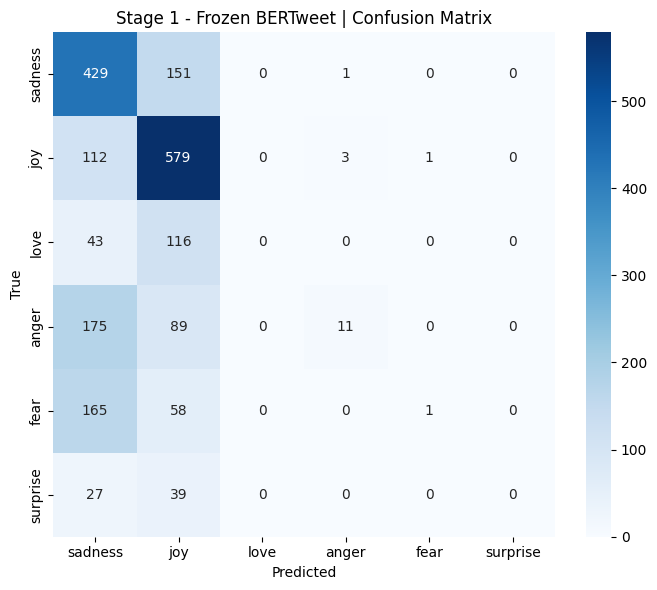

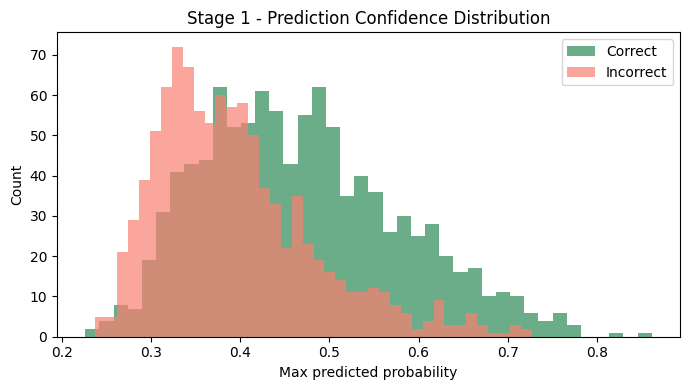

In [14]:
model_s1.eval()
results_s1 = trainer_s1.evaluate(tokenized['test'])
print(results_s1)

preds_s1 = trainer_s1.predict(tokenized['test'])
y_pred_s1 = preds_s1.predictions.argmax(-1)
y_true_s1 = preds_s1.label_ids

plot_confusion_matrix(y_true_s1, y_pred_s1, 'Stage 1 - Frozen BERTweet | Confusion Matrix')
plot_confidence_distribution(preds_s1.predictions, y_true_s1,
                             'Stage 1 - Prediction Confidence Distribution')


## 7. Stage 2 - Custom Deeper Head (frozen encoder)

In [15]:
import torch.nn as nn

model_s2 = load_model(freeze_base=True)

class CLSHead(nn.Module):
    def __init__(self, hidden_size, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels),
        )

    def forward(self, x):
        x = x[:, 0, :]
        return self.net(x)

model_s2.classifier = CLSHead(768, NUM_LABELS)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [16]:
import torch.nn as nn

# Define model_s2 and CLSHead here to ensure it's available when trainer_s2 is initialized.
model_s2 = load_model(freeze_base=True)

class CLSHead(nn.Module):
    def __init__(self, hidden_size, num_labels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_labels),
        )

    def forward(self, x):
        x = x[:, 0, :]
        return self.net(x)

model_s2.classifier = CLSHead(768, NUM_LABELS)

args_s2 = TrainingArguments(
    output_dir='./hf_s2',
    num_train_epochs=3,
    learning_rate=2e-4,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    report_to='none',
)

trainer_s2 = Trainer(
    model=model_s2,
    args=args_s2,
    compute_metrics=compute_metrics,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [17]:
# %%time
trainer_s2.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.522182,1.521638,0.423500,0.175865
2,1.457106,1.413133,0.491000,0.201733
3,1.425340,1.390511,0.502500,0.205067


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1500, training_loss=1.4895684356689454, metrics={'train_runtime': 245.4172, 'train_samples_per_second': 195.585, 'train_steps_per_second': 6.112, 'total_flos': 1577458446336000.0, 'train_loss': 1.4895684356689454, 'epoch': 3.0})

{'eval_loss': 1.3665088415145874, 'eval_accuracy': 0.496, 'eval_f1_macro': 0.20124376671198838, 'eval_runtime': 7.257, 'eval_samples_per_second': 275.594, 'eval_steps_per_second': 8.681, 'epoch': 3.0}


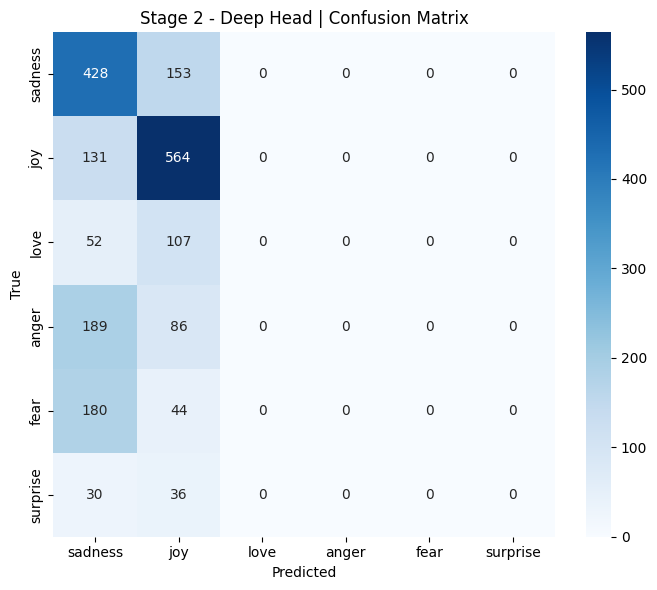

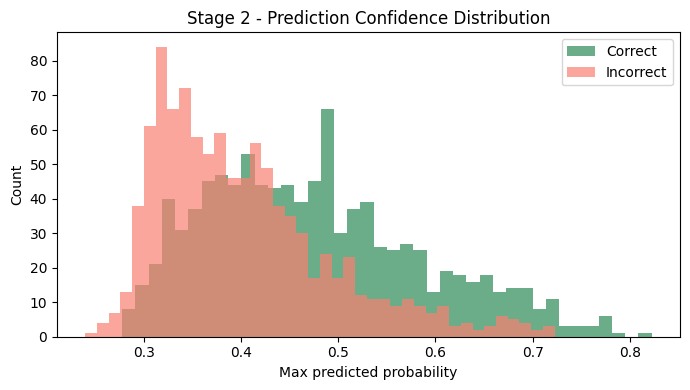

In [18]:
model_s2.eval()
results_s2 = trainer_s2.evaluate(tokenized['test'])
print(results_s2)

preds_s2 = trainer_s2.predict(tokenized['test'])
y_pred_s2 = preds_s2.predictions.argmax(-1)
y_true_s2 = preds_s2.label_ids

plot_confusion_matrix(y_true_s2, y_pred_s2, 'Stage 2 - Deep Head | Confusion Matrix')
plot_confidence_distribution(preds_s2.predictions, y_true_s2,
                             'Stage 2 - Prediction Confidence Distribution')


## 8. Stage 3 - Full Fine-Tuning

In [19]:
model_s3 = load_model(freeze_base=False)

args_s3 = TrainingArguments(
    output_dir='./hf_s3',
    num_train_epochs=3,
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    report_to='none',
)

trainer_s3 = Trainer(
    model=model_s3,
    args=args_s3,
    compute_metrics=compute_metrics,
    train_dataset=tokenized['train'],
    eval_dataset=tokenized['validation'],
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

In [20]:
# %%time
trainer_s3.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.328378,0.261311,0.924000,0.898134
2,0.169594,0.207356,0.922500,0.892285
3,0.127948,0.177172,0.930500,0.901648


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1500, training_loss=0.3567572024663289, metrics={'train_runtime': 638.9789, 'train_samples_per_second': 75.12, 'train_steps_per_second': 2.347, 'total_flos': 1578723028992000.0, 'train_loss': 0.3567572024663289, 'epoch': 3.0})

{'eval_loss': 0.17193882167339325, 'eval_accuracy': 0.927, 'eval_f1_macro': 0.8869604653199407, 'eval_runtime': 7.5493, 'eval_samples_per_second': 264.924, 'eval_steps_per_second': 8.345, 'epoch': 3.0}


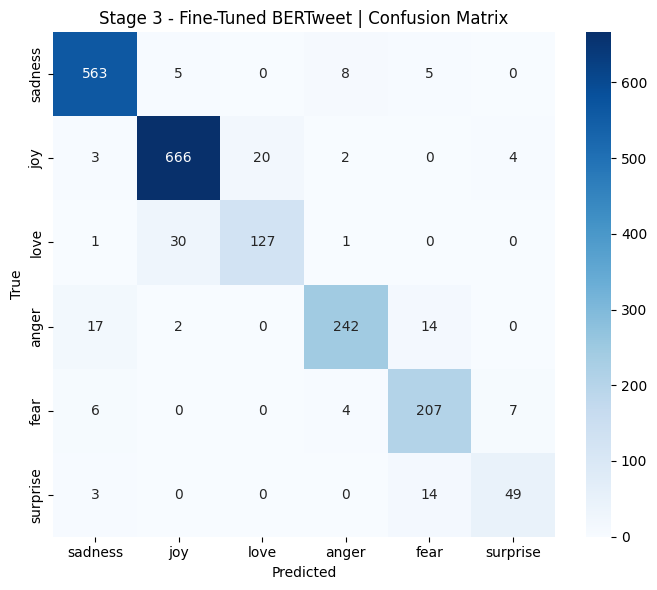

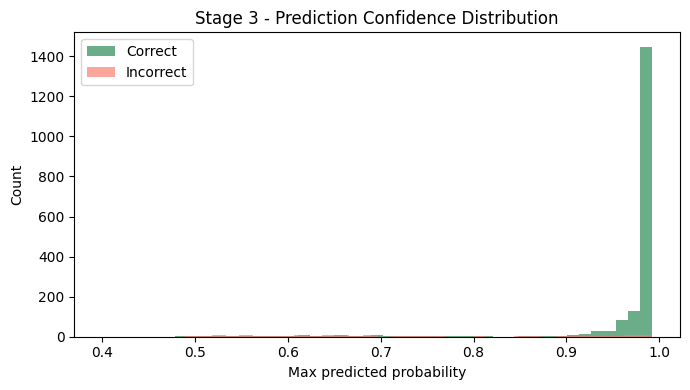

In [21]:
model_s3.eval()
results_s3 = trainer_s3.evaluate(tokenized['test'])
print(results_s3)

preds_s3 = trainer_s3.predict(tokenized['test'])
y_pred_s3 = preds_s3.predictions.argmax(-1)
y_true_s3 = preds_s3.label_ids

plot_confusion_matrix(y_true_s3, y_pred_s3, 'Stage 3 - Fine-Tuned BERTweet | Confusion Matrix')
plot_confidence_distribution(preds_s3.predictions, y_true_s3,
                             'Stage 3 - Prediction Confidence Distribution')


## 9. Cross-Stage Accuracy Comparison

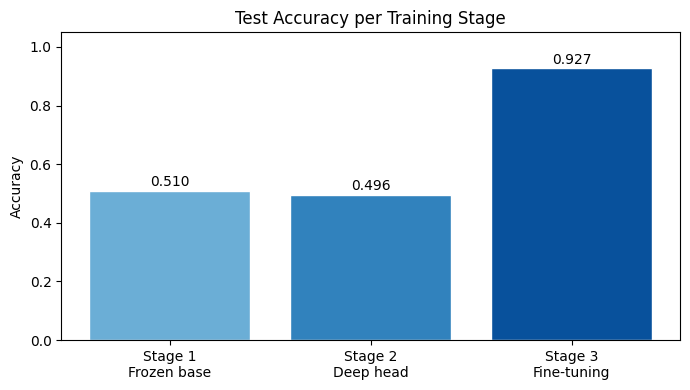

In [22]:
stage_labels = [
    '''Stage 1
Frozen base''',
    '''Stage 2
Deep head''',
    '''Stage 3
Fine-tuning''',
]
accs = [results_s1['eval_accuracy'], results_s2['eval_accuracy'], results_s3['eval_accuracy']]

plt.figure(figsize=(7,4))
bars = plt.bar(stage_labels, accs, color=['#6baed6', '#3182bd', '#08519c'], edgecolor='white')
for b, a in zip(bars, accs):
    plt.text(b.get_x() + b.get_width()/2, a + 0.005, f'{a:.3f}', ha='center', va='bottom')
plt.ylim(0, 1.05)
plt.title('Test Accuracy per Training Stage')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

## 10. Qualitative Error Analysis
**Note:** The table lists **mistakes only**. `true` is the gold label from the dataset, `pred` is the model prediction, and `confidence` is the max softmax probability for the wrong prediction.


In [23]:
import pandas as pd

probs = torch.softmax(torch.tensor(preds_s3.predictions), dim=-1).numpy()
preds = probs.argmax(axis=1)
conf = probs.max(axis=1)

errors = []
for i, (p, y) in enumerate(zip(preds, y_true_s3)):
    if p != y:
        errors.append({
            'text': raw_datasets['test'][i]['text'],
            'true': id2label[y],
            'pred': id2label[p],
            'confidence': conf[i]
        })

errors_df = pd.DataFrame(errors).sort_values('confidence', ascending=False)
errors_df.head(10)


,text,true,pred,confidence
61,whenever i put myself in others shoes and try ...,anger,joy,0.991358
135,i feel underappreciated and under valued,joy,sadness,0.991230
13,i really dont like quinn because i feel like s...,anger,sadness,0.990683
127,i feel much more energized than on a gloomy ra...,sadness,joy,0.989932
52,i was playing a sport in an advanced pe class ...,anger,joy,0.989131
139,i feel inside cause life is like a game someti...,fear,sadness,0.981225
57,i first read this book during college and it h...,fear,sadness,0.977667
23,i am feeling crampy and cranky,anger,fear,0.976854
103,i cannot even begin to express in words the de...,surprise,sadness,0.973095
94,i feel very saddened that the king whom i once...,joy,sadness,0.973031


## 11. Inference on New Examples

In [24]:
from transformers import pipeline

emotion_pipe = pipeline(
    'text-classification',
    model=model_s3,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None,
)

examples = [
    "I just got promoted, I cannot believe it!",
    "Everything feels so dark and hopeless lately.",
    "That jump scare literally made me scream!",
    "You are the most wonderful person I have ever met.",
    "I am absolutely furious about what they did.",
]

for sent in examples:
    result = sorted(emotion_pipe(sent)[0], key=lambda x: -x['score'])
    top = result[0]
    print(f'"{sent}"')
    print(f"  => {top['label']:8s} {top['score']:.2%}")
    print()


"I just got promoted, I cannot believe it!"
  => joy      98.26%

"Everything feels so dark and hopeless lately."
  => sadness  97.93%

"That jump scare literally made me scream!"
  => fear     91.94%

"You are the most wonderful person I have ever met."
  => joy      94.95%

"I am absolutely furious about what they did."
  => anger    96.22%



## 12. Model Comparison - BERTweet base vs large

**Note:** We compare full fine-tuning results for base vs large. The large model is heavier; reduce batch size if needed.


Large model: vinai/bertweet-large


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.317652,0.308359,0.908000,0.881641
2,0.131865,0.182887,0.934500,0.906779
3,0.094322,0.139008,0.942000,0.916462


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

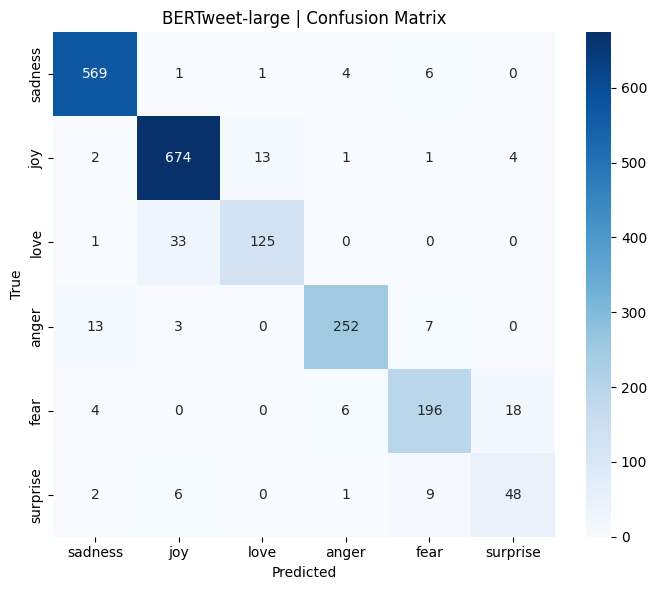

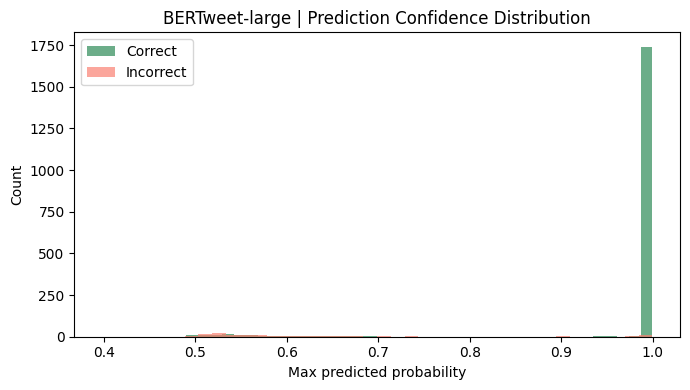

,model,accuracy,f1_macro
0,bertweet-base,0.927,0.886960
1,bertweet-large,0.932,0.881736


In [25]:
RUN_LARGE = True

if RUN_LARGE:
    print('Large model:', LARGE_CKPT)
    tokenizer_large = AutoTokenizer.from_pretrained(LARGE_CKPT, use_fast=False)
    tokenized_large = raw_datasets.map(
        lambda batch: tokenizer_large(batch['text'], max_length=MAX_LEN, truncation=True, padding='max_length'),
        batched=True
    )

    model_large = AutoModelForSequenceClassification.from_pretrained(
        LARGE_CKPT,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id
    )
    print('Loaded large model:', model_large.config.name_or_path)

    large_batch = 16 if IN_COLAB else 8
    args_large = TrainingArguments(
        output_dir='./hf_large',
        num_train_epochs=3,
        learning_rate=2e-5,
        per_device_train_batch_size=large_batch,
        per_device_eval_batch_size=large_batch,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        logging_steps=50,
        report_to='none',
    )

    trainer_large = Trainer(
        model=model_large,
        args=args_large,
        compute_metrics=compute_metrics,
        train_dataset=tokenized_large['train'],
        eval_dataset=tokenized_large['validation'],
    )

    trainer_large.train()
    results_large = trainer_large.evaluate(tokenized_large['test'])
    preds_large = trainer_large.predict(tokenized_large['test'])

    # Large model diagnostics
    y_pred_large = preds_large.predictions.argmax(-1)
    y_true_large = preds_large.label_ids

    plot_confusion_matrix(y_true_large, y_pred_large,
                          'BERTweet-large | Confusion Matrix')
    plot_confidence_distribution(preds_large.predictions, y_true_large,
                                 'BERTweet-large | Prediction Confidence Distribution')

    comparison_df = pd.DataFrame({
        'model': ['bertweet-base', 'bertweet-large'],
        'accuracy': [results_s3['eval_accuracy'], results_large['eval_accuracy']],
        'f1_macro': [results_s3['eval_f1_macro'], results_large['eval_f1_macro']]
    })
    display(comparison_df)

## 13. Predictions vs. Ground Truth

**Note:** This table shows both correct and incorrect predictions. It includes the gold label (`true`), the model prediction (`pred`), and the confidence for the predicted class.


**Note:** The table below uses the base model (Stage 3). If you run the large model comparison, you can duplicate this block to inspect large-model predictions.


In [26]:
import pandas as pd

probs = torch.softmax(torch.tensor(preds_s3.predictions), dim=-1).numpy()
preds = probs.argmax(axis=1)
conf = probs.max(axis=1)

rows = []
for i, (p, y) in enumerate(zip(preds, y_true_s3)):
    rows.append({
        'text': raw_datasets['test'][i]['text'],
        'true': id2label[y],
        'pred': id2label[p],
        'confidence': conf[i],
        'correct': p == y
    })

pred_df = pd.DataFrame(rows)
# Show a balanced view: top confident correct and incorrect
top_correct = pred_df[pred_df['correct']].sort_values('confidence', ascending=False).head(10)
top_incorrect = pred_df[~pred_df['correct']].sort_values('confidence', ascending=False).head(10)
pd.concat([top_correct, top_incorrect])


,text,true,pred,confidence,correct
332,i have better things to do than to feel humili...,sadness,sadness,0.992736,True
1191,i never been feel this ashame this humiliated ...,sadness,sadness,0.992733,True
1378,i am up and ready to read read read today even...,sadness,sadness,0.992732,True
1631,i was feeling really troubled and down over wh...,sadness,sadness,0.992727,True
1098,i feel burdened and stuck in the center of a d...,sadness,sadness,0.992726,True
1396,i appreciate how clean their lifestyles are ev...,sadness,sadness,0.992722,True
443,i woke up feeling groggy and grumpy and like t...,sadness,sadness,0.992720,True
1615,i cant helped but to feel burdened and anxious...,sadness,sadness,0.992718,True
912,i went to training feeling very disheartened,sadness,sadness,0.992709,True
887,i will remember to come to you when i feel bea...,sadness,sadness,0.992707,True


## 14. Conclusions

### Key findings
1. **BERTweet base vs large is a trade-off.** Large slightly improves accuracy, but macro-F1 does not improve here.
2. **Fine-tuning yields the biggest gains overall.** Stage 3 improves both accuracy and class coverage compared to frozen stages.
3. **Class imbalance remains the main source of error.** Minority classes (*love*, *surprise*) still lag in recall, regardless of model size.
4. **Most confusions are semantically plausible.** The dominant error pairs remain **sadness ↔ fear** and **joy ↔ love**.

### Model comparison (this run)
- `bertweet-base`: accuracy ~0.927, macro-F1 ~0.887
- `bertweet-large`: accuracy ~0.932, macro-F1 ~0.882
- **Interpretation:** large gives a small accuracy lift but does not improve macro-F1; this suggests the gain is concentrated in majority classes.

### Practical takeaways
- If you care about overall accuracy, large can be worth the extra cost.
- If you care about minority-class balance (macro-F1), base is competitive here.
- Use class-weighted loss or focal loss if minority recall is your priority.
